# Module 2 — Lab 2: NLP Feature Engineering & Target Encoding
## POS Tagging, Count Vectorization, Word Cloud, Amenities Score & Sub-Area Encoding

---

### Lab Overview

Property descriptions contain pricing signals that structured features alone cannot capture. "Panoramic sea view" and "modular kitchen" carry value information invisible to numerical features. In this lab you will:

1. Create a **word cloud** to visually understand the description vocabulary
2. Extract NLP features using **POS tagging** and **Count Vectorization** with bigrams
3. Engineer **target-encoded features** — average price by sub-area and by amenity bundle
4. Combine structural, NLP, and encoded features into the final model-ready matrix

| Step | Technique | Feature Produced |
|------|-----------|-----------------|
| 1 | Word cloud | Visual understanding (no numeric feature) |
| 2 | POS tagging | noun_count, adj_count, verb_count per property |
| 3 | Count Vectorization + bigrams | Sparse text matrix (top features) |
| 4 | Target encoding (sub-area) | avg price by neighbourhood |
| 5 | Amenities score + encoding | composite score + avg price by score |

---

## 1. Environment Setup

In [ ]:
# Uncomment if packages not installed
!pip install pandas numpy nltk scikit-learn scipy matplotlib wordcloud -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
import pickle
from collections import Counter

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

print("✅ All libraries imported and NLTK data downloaded")

✅ All libraries imported and NLTK data downloaded


## 2. Load Cleaned Data from Lab 1

In [ ]:
# ── Load ──
df = pd.read_csv('data_cleaned.csv')
print(f"✅ Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head(3))

✅ Loaded: 199 rows × 17 columns


,City,State,Country,Property Type Cleaned,Sub-Area Cleaned,Company Name Cleaned,TownShip Cleaned,Description Cleaned,ClubHouse Cleaned,School Cleaned,Hospital Cleaned,Mall Cleaned,Park Cleaned,Pool Cleaned,Gym Cleaned,Area Cleaned,Price Cleaned
0,pune,maharashtra,india,1.0,bavdhan,shapoorji paloonji,vanaha,shapoorji paloonji comunity located in the sub...,1,1,1,1,1,1,1,492.0,39.0
1,pune,maharashtra,india,2.0,bavdhan,shapoorji paloonji,vanaha,vanaha township located near the lonavala hill...,1,1,1,1,1,1,1,774.0,65.0
2,pune,maharashtra,india,3.0,bavdhan,shapoorji paloonji,vanaha,vanaha society is suitable for all aged group ...,1,1,1,1,1,1,1,889.0,74.0


## 3. Word Cloud — Visual Vocabulary Exploration

Before applying NLP techniques, let's see what words dominate the property descriptions. The word cloud gives an instant visual answer.

In [ ]:
stop_words = set(stopwords.words('english'))
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

<>:6: SyntaxWarning: invalid escape sequence '\['
<>:6: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_11672/1317633357.py:6: SyntaxWarning: invalid escape sequence '\['
  REPLACE_BY_SPACE = re.compile("[/(){}\[\]\|@,;!]")


Total words in corpus: 4539


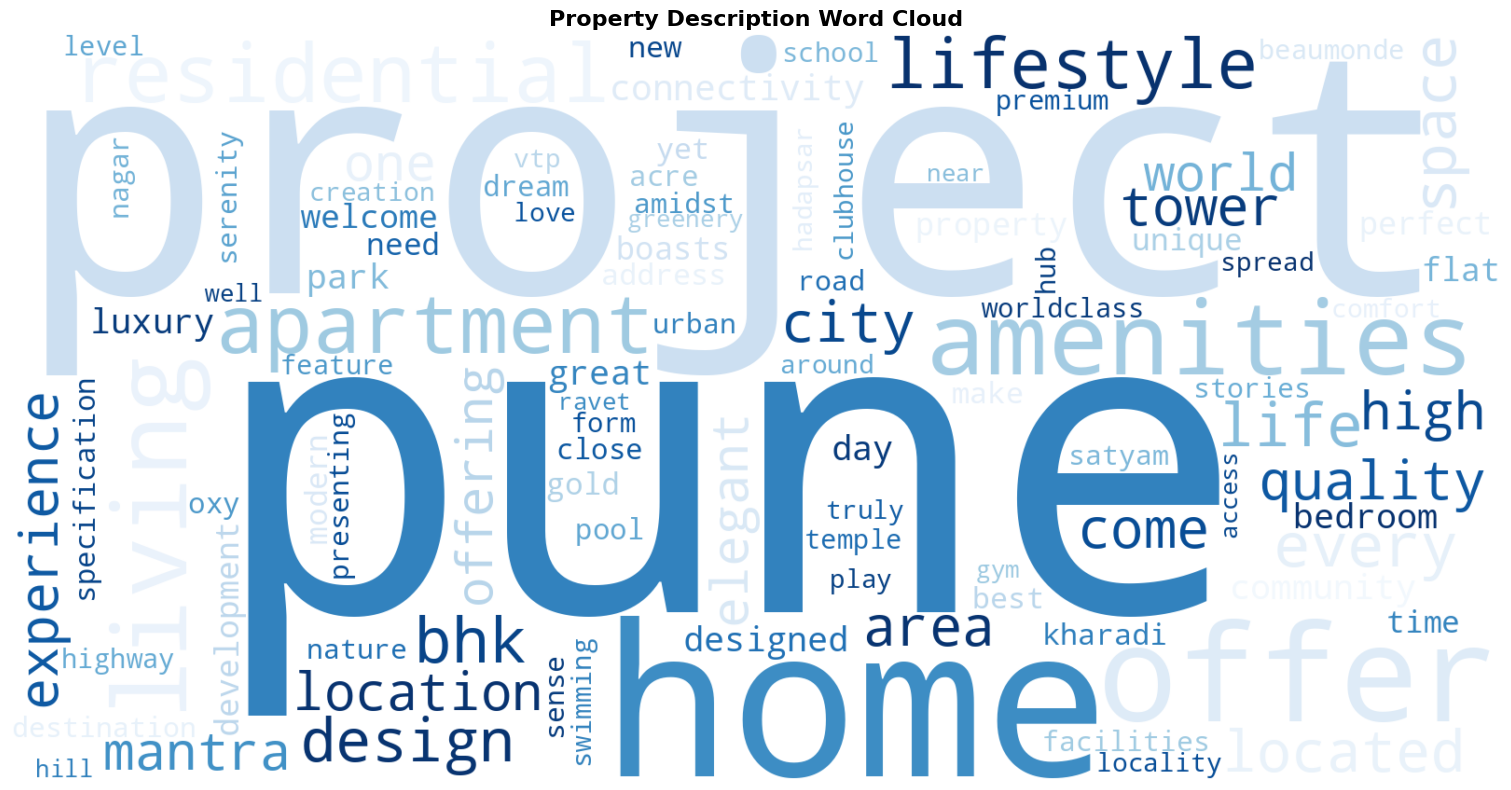


💡 Dominant words tell you what sellers emphasize:
   Look for amenity words (pool, gym), quality words (luxury, modern), location words


In [ ]:
# ── Text preprocessing for word cloud ──
from wordcloud import WordCloud

stop_words = set(stopwords.words('english'))

REPLACE_BY_SPACE = re.compile("[/(){}\[\]\|@,;!]")
BAD_SYMBOLS = re.compile("[^0-9a-z #+_]")

def text_prepare(text):
    """Clean text: lowercase, remove special chars, remove stopwords."""
    text = str(text).lower()
    text = REPLACE_BY_SPACE.sub(' ', text)
    text = BAD_SYMBOLS.sub('', text)
    text = ' '.join(w for w in text.split() if w not in stop_words and len(w) > 2)
    return text

df['Description Processed'] = df['Description Cleaned'].apply(text_prepare)

# Build word cloud
all_text = " ".join(df['Description Processed'])
print(f"Total words in corpus: {len(all_text.split())}")

wordcloud = WordCloud(
    background_color='white', width=1600, height=800,
    collocations=False, max_words=100,
    colormap='Blues'
).generate(all_text)

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Property Description Word Cloud', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Dominant words tell you what sellers emphasize:")
print("   Look for amenity words (pool, gym), quality words (luxury, modern), location words")

## 4. POS Tagging — Extract Nouns, Adjectives, Verbs

Parts of Speech tagging labels each word with its grammatical role:
- **Nouns (NN, NNS)** → amenities and objects: pool, garden, kitchen
- **Adjectives (JJ)** → quality signals: spacious, modern, luxurious
- **Verbs (VB)** → action context: offering, located, featuring

In [ ]:
# ── POS tagging ──
def extract_pos_counts(text):
    """Count nouns, verbs, adjectives in text."""
    if pd.isna(text) or text == "":
        return 0, 0, 0
    tokens = word_tokenize(str(text))
    tagged = pos_tag(tokens)
    nouns = sum(1 for _, tag in tagged if tag in ('NN', 'NNS', 'NNP'))
    verbs = sum(1 for _, tag in tagged if tag.startswith('VB'))
    adjs = sum(1 for _, tag in tagged if tag in ('JJ', 'JJR', 'JJS'))
    return nouns, verbs, adjs

# Apply (this takes a few seconds)
print("Extracting POS features...")
pos_results = df['Description Processed'].apply(extract_pos_counts)
df['Noun_Counts'] = pos_results.apply(lambda x: x[0])
df['Verb_Counts'] = pos_results.apply(lambda x: x[1])
df['Adjective_Counts'] = pos_results.apply(lambda x: x[2])

print("\nPOS Feature Statistics:")
for col in ['Noun_Counts', 'Verb_Counts', 'Adjective_Counts']:
    print(f"  {col:20s} → mean={df[col].mean():.1f}, max={df[col].max()}")

Extracting POS features...

POS Feature Statistics:
  Noun_Counts          → mean=11.9, max=22
  Verb_Counts          → mean=4.3, max=11
  Adjective_Counts     → mean=4.6, max=12


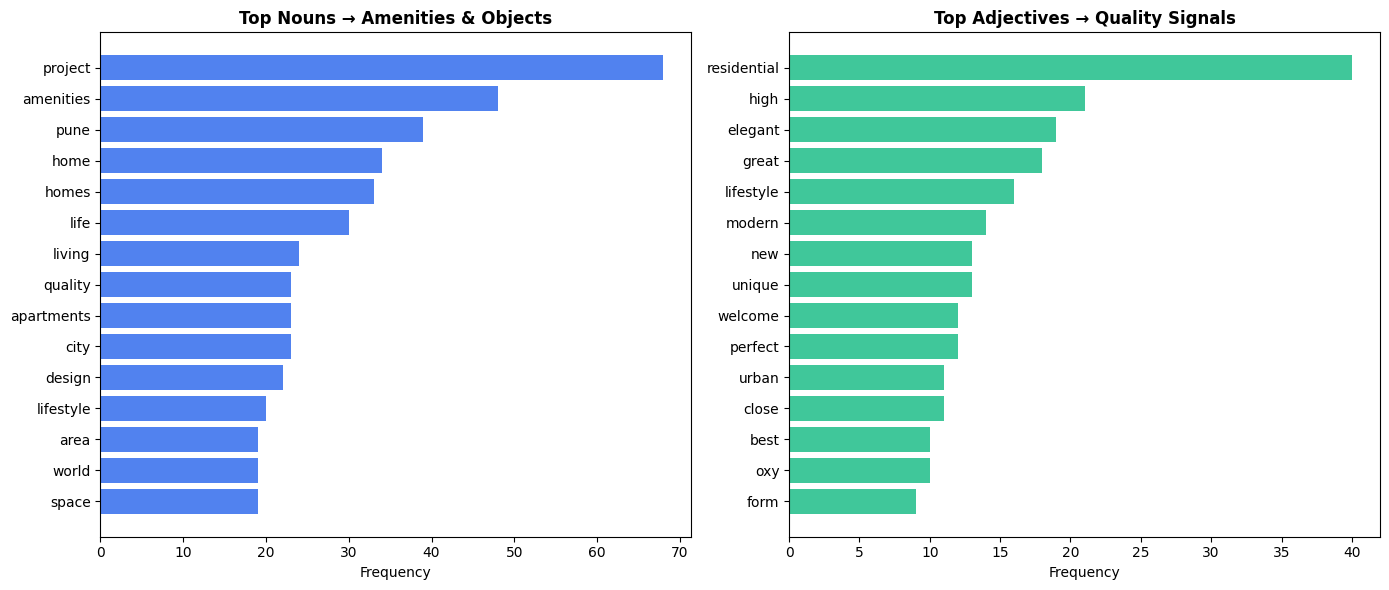

In [ ]:
# ── Visualize top nouns and adjectives ──
def get_top_pos_words(texts, target_tags, top_n=15):
    """Extract the most common words with specific POS tags."""
    words = []
    for text in texts:
        if pd.isna(text): continue
        tokens = word_tokenize(str(text))
        tagged = pos_tag(tokens)
        words.extend([w for w, t in tagged if t in target_tags])
    return Counter(words).most_common(top_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top nouns
noun_counts = get_top_pos_words(df['Description Processed'], ('NN', 'NNS', 'NNP'))
if noun_counts:
    words, counts = zip(*noun_counts)
    axes[0].barh(range(len(words)), counts, color='#2563eb', alpha=0.8)
    axes[0].set_yticks(range(len(words)))
    axes[0].set_yticklabels(words)
    axes[0].invert_yaxis()
    axes[0].set_title('Top Nouns → Amenities & Objects', fontweight='bold')
    axes[0].set_xlabel('Frequency')

# Top adjectives
adj_counts = get_top_pos_words(df['Description Processed'], ('JJ', 'JJR', 'JJS'))
if adj_counts:
    words, counts = zip(*adj_counts)
    axes[1].barh(range(len(words)), counts, color='#10b981', alpha=0.8)
    axes[1].set_yticks(range(len(words)))
    axes[1].set_yticklabels(words)
    axes[1].invert_yaxis()
    axes[1].set_title('Top Adjectives → Quality Signals', fontweight='bold')
    axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

## 5. Count Vectorization with Bigrams

Bigram matrix shape: (199, 10)
  199 documents × 10 bigram features

Bigrams selected: ['bedroom apartment', 'boasts elegant', 'elegant towers', 'great community', 'mantra gold', 'offering bedroom', 'project boasts', 'project offers', 'stories offering', 'towers stories']
Sparsity: 94.4%


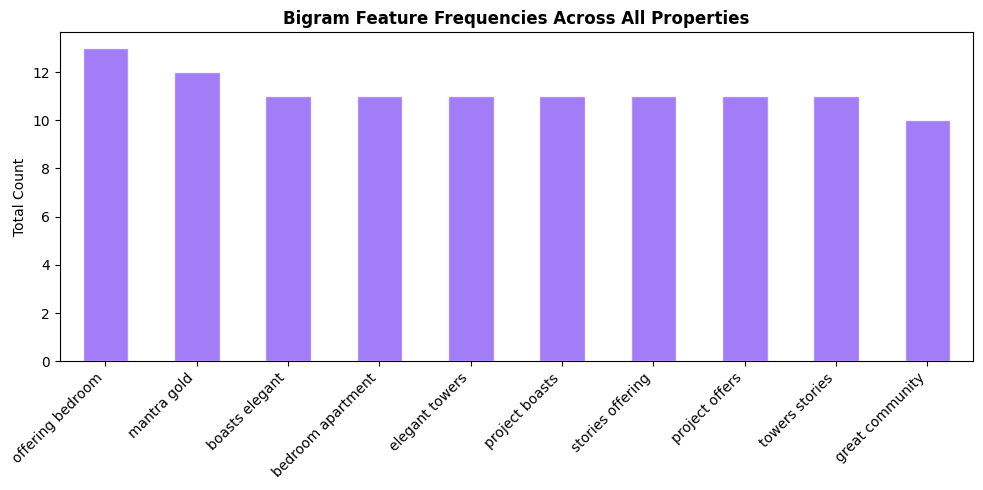

In [ ]:
# ── Fit Count Vectorizer with bigrams ──
cv = CountVectorizer(ngram_range=(2, 2), max_features=10, stop_words='english')
cv.fit(df['Description Processed'])

text_matrix = cv.transform(df['Description Processed'])

print(f"Bigram matrix shape: {text_matrix.shape}")
print(f"  {text_matrix.shape[0]} documents × {text_matrix.shape[1]} bigram features")
print(f"\nBigrams selected: {cv.get_feature_names_out().tolist()}")
print(f"Sparsity: {(1 - text_matrix.nnz / (text_matrix.shape[0] * text_matrix.shape[1])) * 100:.1f}%")

# Convert to DataFrame for inspection
text_df = pd.DataFrame(text_matrix.toarray(), columns=cv.get_feature_names_out(), index=df.index)

# Visualize bigram frequencies
fig, ax = plt.subplots(figsize=(10, 5))
feature_totals = text_df.sum().sort_values(ascending=False)
feature_totals.plot(kind='bar', color='#8b5cf6', alpha=0.8, ax=ax, edgecolor='white')
ax.set_title('Bigram Feature Frequencies Across All Properties', fontweight='bold')
ax.set_ylabel('Total Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# ── Save vectorizer for inference (Lab 4 will need it) ──
import os
os.makedirs('model', exist_ok=True)

pickle.dump(cv, open('model/count_vectorizer.pkl', 'wb'))
print("✅ CountVectorizer saved to model/count_vectorizer.pkl")

✅ CountVectorizer saved to model/count_vectorizer.pkl


In [ ]:
df.head()

,City,State,Country,Property Type Cleaned,Sub-Area Cleaned,Company Name Cleaned,TownShip Cleaned,Description Cleaned,ClubHouse Cleaned,School Cleaned,...,Mall Cleaned,Park Cleaned,Pool Cleaned,Gym Cleaned,Area Cleaned,Price Cleaned,Description Processed,Noun_Counts,Verb_Counts,Adjective_Counts
0,pune,maharashtra,india,1.0,bavdhan,shapoorji paloonji,vanaha,shapoorji paloonji comunity located in the sub...,1,1,...,1,1,1,1,492.0,39.0,shapoorji paloonji comunity located suburbs ba...,13,7,2
1,pune,maharashtra,india,2.0,bavdhan,shapoorji paloonji,vanaha,vanaha township located near the lonavala hill...,1,1,...,1,1,1,1,774.0,65.0,vanaha township located near lonavala hill ran...,10,5,2
2,pune,maharashtra,india,3.0,bavdhan,shapoorji paloonji,vanaha,vanaha society is suitable for all aged group ...,1,1,...,1,1,1,1,889.0,74.0,vanaha society suitable aged group people play...,12,6,2
3,pune,maharashtra,india,3.0,bavdhan,shapoorji paloonji,vanaha,vanaha township are offering 3bhk grand prpoer...,1,1,...,1,1,1,1,1018.0,89.0,vanaha township offering 3bhk grand prpoerties...,12,4,2
4,pune,maharashtra,india,2.0,mahalunge,godrej properties,godrej hills retreat,the area is a hub of prestigious schools like ...,1,1,...,1,1,1,1,743.0,74.0,area hub prestigious schools like bishops high...,14,2,6


## 6. Target Encoding — Sub-Area Price and Amenities Score

Target encoding creates features by computing the mean target value (price) for each category. This captures the "neighbourhood premium" and "amenity bundle value" that raw features miss.

**⚠️ Caution:** Target encoding uses the target variable to create features. In production, this creates a leak risk. For this project with 200 samples, we apply it on the full dataset for simplicity. In later modules (spine project), you'll learn proper fold-based target encoding.

In [ ]:
# ── 6.1 Average Price by Sub-Area ──
sub_area_price_map = df.groupby('Sub-Area Cleaned')['Price Cleaned'].mean().to_dict()

df['Price by sub-area'] = df['Sub-Area Cleaned'].map(sub_area_price_map)

# Show top sub-areas by average price
top_areas = sorted(sub_area_price_map.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 Sub-Areas by Average Price:")
for area, price in top_areas:
    print(f"  {area:25s} → ₹{price:.1f} lakhs")

# Check correlation with target
corr = df['Price by sub-area'].corr(df['Price Cleaned'])
print(f"\nCorrelation with Price: {corr:.3f} ← strong signal!")

# Save mapping for inference
pickle.dump(sub_area_price_map, open('model/sub_area_price_map.pkl', 'wb'))
print("✅ Sub-area price map saved")

Top 10 Sub-Areas by Average Price:
  kayani nagar              → ₹190.3 lakhs
  lonavala                  → ₹174.6 lakhs
  nibm                      → ₹145.6 lakhs
  koregoan                  → ₹139.5 lakhs
  karvanagar                → ₹135.8 lakhs
  baner                     → ₹133.0 lakhs
  vimannagar                → ₹127.5 lakhs
  akurdi                    → ₹109.7 lakhs
  koregaon park             → ₹108.5 lakhs
  bt kawade rd              → ₹106.0 lakhs

Correlation with Price: 0.746 ← strong signal!
✅ Sub-area price map saved


Amenities Score distribution:
Amenities score
1    21
2    29
3    46
4    97
7     6
Name: count, dtype: int64


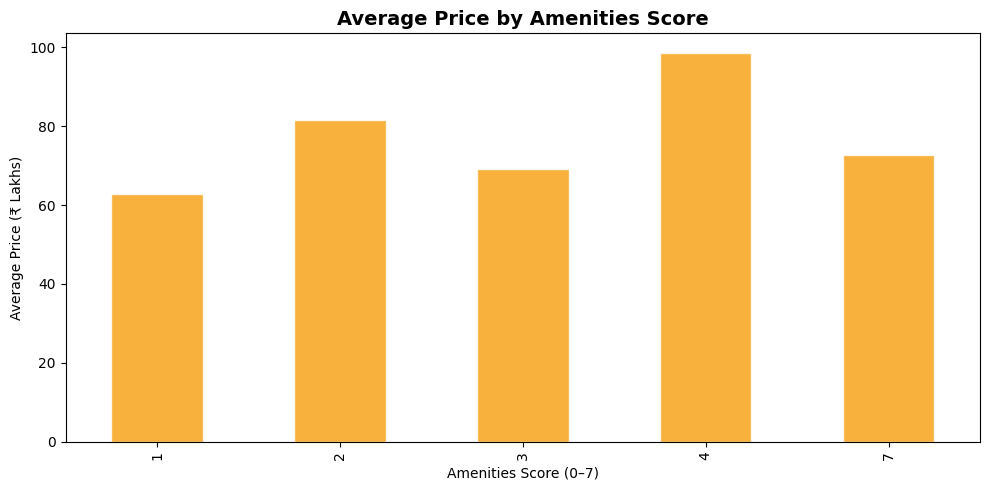


Correlation (Amenities Score vs Price): 0.196
✅ Amenities score price map saved


In [ ]:
# ── 6.2 Amenities Score (composite of 7 binary features) ──
amenity_cols = ['ClubHouse Cleaned', 'School Cleaned', 'Hospital Cleaned',
                'Mall Cleaned', 'Park Cleaned', 'Pool Cleaned', 'Gym Cleaned']

df['Amenities score'] = df[amenity_cols].sum(axis=1)

print("Amenities Score distribution:")
print(df['Amenities score'].value_counts().sort_index())

# Average price by amenities score
amenities_price_map = df.groupby('Amenities score')['Price Cleaned'].mean().to_dict()
df['Price by Amenities score'] = df['Amenities score'].map(amenities_price_map)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
score_means = df.groupby('Amenities score')['Price Cleaned'].mean().sort_index()
score_means.plot(kind='bar', color='#f59e0b', alpha=0.8, ax=ax, edgecolor='white')
ax.set_title('Average Price by Amenities Score', fontweight='bold', fontsize=14)
ax.set_xlabel('Amenities Score (0–7)')
ax.set_ylabel('Average Price (₹ Lakhs)')
plt.tight_layout()
plt.show()

corr = df['Amenities score'].corr(df['Price Cleaned'])
print(f"\nCorrelation (Amenities Score vs Price): {corr:.3f}")

# Save mapping for inference
pickle.dump(amenities_price_map, open('model/amenities_score_price_map.pkl', 'wb'))
print("✅ Amenities score price map saved")

## 7. Combine All Features into Final Matrix

In [ ]:
# ── Build the final feature set ──

# Structural + engineered features
feature_cols = [
    'Property Type Cleaned', 'Area Cleaned',
    'ClubHouse Cleaned', 'School Cleaned', 'Hospital Cleaned',
    'Mall Cleaned', 'Park Cleaned', 'Pool Cleaned', 'Gym Cleaned',
    'Price by sub-area', 'Amenities score', 'Price by Amenities score',
    'Noun_Counts', 'Verb_Counts', 'Adjective_Counts',
]

# Structural features as DataFrame
X_structural = df[feature_cols].fillna(0)

# Add bigram features
X_combined = pd.concat([X_structural.reset_index(drop=True), text_df.reset_index(drop=True)], axis=1)

# Target
y = df['Price Cleaned'].values

print(f"Feature matrix summary:")
print(f"  Structural + engineered features: {len(feature_cols)}")
print(f"  Bigram text features: {text_df.shape[1]}")
print(f"  Combined shape: {X_combined.shape}")
print(f"  Target shape: {y.shape}")
print(f"\nAll feature columns:")
for i, col in enumerate(X_combined.columns, 1):
    print(f"  {i:2d}. {col}")

Feature matrix summary:
  Structural + engineered features: 15
  Bigram text features: 10
  Combined shape: (199, 25)
  Target shape: (199,)

All feature columns:
   1. Property Type Cleaned
   2. Area Cleaned
   3. ClubHouse Cleaned
   4. School Cleaned
   5. Hospital Cleaned
   6. Mall Cleaned
   7. Park Cleaned
   8. Pool Cleaned
   9. Gym Cleaned
  10. Price by sub-area
  11. Amenities score
  12. Price by Amenities score
  13. Noun_Counts
  14. Verb_Counts
  15. Adjective_Counts
  16. bedroom apartment
  17. boasts elegant
  18. elegant towers
  19. great community
  20. mantra gold
  21. offering bedroom
  22. project boasts
  23. project offers
  24. stories offering
  25. towers stories


In [ ]:
X_combined

,Property Type Cleaned,Area Cleaned,ClubHouse Cleaned,School Cleaned,Hospital Cleaned,Mall Cleaned,Park Cleaned,Pool Cleaned,Gym Cleaned,Price by sub-area,...,bedroom apartment,boasts elegant,elegant towers,great community,mantra gold,offering bedroom,project boasts,project offers,stories offering,towers stories
0,1.0,492.0,1,1,1,1,1,1,1,58.044000,...,0,0,0,0,0,0,0,0,0,0
1,2.0,774.0,1,1,1,1,1,1,1,58.044000,...,0,0,0,0,0,0,0,0,0,0
2,3.0,889.0,1,1,1,1,1,1,1,58.044000,...,0,0,0,0,0,0,0,0,0,0
3,3.0,1018.0,1,1,1,1,1,1,1,58.044000,...,0,0,0,0,0,0,0,0,0,0
4,2.0,743.0,1,1,1,1,1,1,1,73.555556,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,3.0,1350.0,1,0,0,0,1,1,1,132.965000,...,0,0,0,0,0,0,0,0,0,0
195,4.0,1600.0,1,0,0,0,1,1,1,132.965000,...,0,0,0,0,0,0,0,0,0,0
196,2.0,789.0,0,0,0,0,1,1,1,132.965000,...,0,0,0,0,0,0,0,0,0,0
197,3.0,1107.0,0,0,0,0,1,1,1,132.965000,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Property Type Cleaned     199 non-null    float64
 1   Area Cleaned              199 non-null    float64
 2   ClubHouse Cleaned         199 non-null    int64  
 3   School Cleaned            199 non-null    int64  
 4   Hospital Cleaned          199 non-null    int64  
 5   Mall Cleaned              199 non-null    int64  
 6   Park Cleaned              199 non-null    int64  
 7   Pool Cleaned              199 non-null    int64  
 8   Gym Cleaned               199 non-null    int64  
 9   Price by sub-area         199 non-null    float64
 10  Amenities score           199 non-null    int64  
 11  Price by Amenities score  199 non-null    float64
 12  Noun_Counts               199 non-null    int64  
 13  Verb_Counts               199 non-null    int64  
 14  Adjective_

In [ ]:
# ── Save everything for Lab 3 ──
# Save combined features and target
X_combined.to_csv('model_features.csv', index=False)
np.save('model_target.npy', y)

# Save metadata for inference
pickle.dump(feature_cols, open('model/feature_cols.pkl', 'wb'))
pickle.dump(X_combined.columns.tolist(), open('model/all_feature_names.pkl', 'wb'))

# Save the full DataFrame for reference
df.to_csv('data_with_features.csv', index=False)

print("✅ Saved for Lab 3:")
print("   model_features.csv      — combined feature matrix")
print("   model_target.npy        — target variable (Price)")
print("   model/count_vectorizer.pkl")
print("   model/sub_area_price_map.pkl")
print("   model/amenities_score_price_map.pkl")
print("   model/feature_cols.pkl")
print("   model/all_feature_names.pkl")

✅ Saved for Lab 3:
   model_features.csv      — combined feature matrix
   model_target.npy        — target variable (Price)
   model/count_vectorizer.pkl
   model/sub_area_price_map.pkl
   model/amenities_score_price_map.pkl
   model/feature_cols.pkl
   model/all_feature_names.pkl


In [ ]:
!zip -r model.zip model/ model_features.csv model_target.npy

  adding: model/ (stored 0%)
  adding: model/feature_cols.pkl (deflated 40%)
  adding: model/count_vectorizer.pkl (deflated 39%)
  adding: model/all_feature_names.pkl (deflated 43%)
  adding: model/sub_area_price_map.pkl (deflated 29%)
  adding: model/amenities_score_price_map.pkl (deflated 3%)
  adding: model_features.csv (deflated 86%)
  adding: model_target.npy (deflated 62%)


---

## 8. Conclusion & Next Steps

| Technique | Feature(s) Produced | Key Insight |
|-----------|-------------------|-------------|
| **Word Cloud** | Visual exploration | See dominant vocabulary before coding NLP |
| **POS Tagging** | Noun/Verb/Adj counts | Nouns capture amenities, adjectives capture quality |
| **Count Vectorization** | 10 bigram columns | Multi-word phrases ("world class", "quality specification") |
| **Target Encoding (Sub-Area)** | Price by sub-area | Neighbourhood premium — strongest engineered feature |
| **Amenities Score** | Composite 0–7 score | Bundle value > individual amenities |
| **Target Encoding (Amenities)** | Price by Amenities score | Non-linear relationship between amenity count and price |

### Try on Your Own
1. Try trigrams (`ngram_range=(3,3)`) — do they capture useful phrases?
2. Increase `max_features` to 20 or 50 in the CountVectorizer — does it help?
3. Create "price per sq ft by sub-area" as an alternative to raw price encoding
4. Experiment with TF-IDF instead of raw counts — does it change feature importance?

---

**Next Lab:** Module 2, Lab 3 — Model Building, Evaluation & Serialization 📊